# F1 Race Data â€” Exploratory Data Analysis

Exploring 2018â€“2024 F1 race results + weather data collected via FastF1 and Open-Meteo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 40)

DATA_DIR = Path("..") / "data" / "raw"
df = pd.read_parquet(DATA_DIR / "all_races.parquet")
print(f"Shape: {df.shape}")
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Races per season: {df.groupby('season')['round'].nunique().to_dict()}")
df.head()

Shape: (2979, 36)
Seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Races per season: {2018: 21, 2019: 21, 2020: 17, 2021: 22, 2022: 22, 2023: 22, 2024: 24}


,season,round,event_name,location,country,event_date,driver_number,driver_abbrev,driver_id,first_name,last_name,team,team_id,finish_position,grid_position,status,points,laps_completed,is_classified,q1_time_sec,q2_time_sec,q3_time_sec,race_time_sec,f1_air_temp_mean,f1_track_temp_mean,f1_humidity_mean,f1_pressure_mean,f1_wind_speed_mean,f1_rainfall,weather_temp_max,weather_temp_min,weather_precip_mm,weather_wind_max_kph,is_podium,is_points_finish,is_dnf
0,2018,1,Australian Grand Prix,Melbourne,Australia,2018-03-25,5,VET,vettel,Sebastian,Vettel,Ferrari,ferrari,1.0,3.0,Finished,25.0,58,True,None,None,None,5373.283,24.077477,36.324324,30.915315,997.003604,3.691892,True,23.4,11.1,5.2,39.8,True,True,False
1,2018,1,Australian Grand Prix,Melbourne,Australia,2018-03-25,44,HAM,hamilton,Lewis,Hamilton,Mercedes,mercedes,2.0,1.0,Finished,18.0,58,True,None,None,None,5.036,24.077477,36.324324,30.915315,997.003604,3.691892,True,23.4,11.1,5.2,39.8,True,True,False
2,2018,1,Australian Grand Prix,Melbourne,Australia,2018-03-25,7,RAI,raikkonen,Kimi,Räikkönen,Ferrari,ferrari,3.0,2.0,Finished,15.0,58,True,None,None,None,6.309,24.077477,36.324324,30.915315,997.003604,3.691892,True,23.4,11.1,5.2,39.8,True,True,False
3,2018,1,Australian Grand Prix,Melbourne,Australia,2018-03-25,3,RIC,ricciardo,Daniel,Ricciardo,Red Bull Racing,red_bull,4.0,8.0,Finished,12.0,58,True,None,None,None,7.069,24.077477,36.324324,30.915315,997.003604,3.691892,True,23.4,11.1,5.2,39.8,False,True,False
4,2018,1,Australian Grand Prix,Melbourne,Australia,2018-03-25,14,ALO,alonso,Fernando,Alonso,McLaren,mclaren,5.0,10.0,Finished,10.0,58,True,None,None,None,27.886,24.077477,36.324324,30.915315,997.003604,3.691892,True,23.4,11.1,5.2,39.8,False,True,False


## 1. Dataset Overview

In [2]:
print("Column types:")
print(df.dtypes.to_string())
print(f"\nNull counts:")
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False).to_string())

Column types:
season                    int64
round                     int64
event_name               object
location                 object
country                  object
event_date               object
driver_number            object
driver_abbrev            object
driver_id                object
first_name               object
last_name                object
team                     object
team_id                  object
finish_position         float64
grid_position           float64
status                   object
points                  float64
laps_completed            int64
is_classified              bool
q1_time_sec              object
q2_time_sec              object
q3_time_sec              object
race_time_sec           float64
f1_air_temp_mean        float64
f1_track_temp_mean      float64
f1_humidity_mean        float64
f1_pressure_mean        float64
f1_wind_speed_mean      float64
f1_rainfall                bool
weather_temp_max        float64
weather_temp_min        fl

## 2. Finish Position Distribution

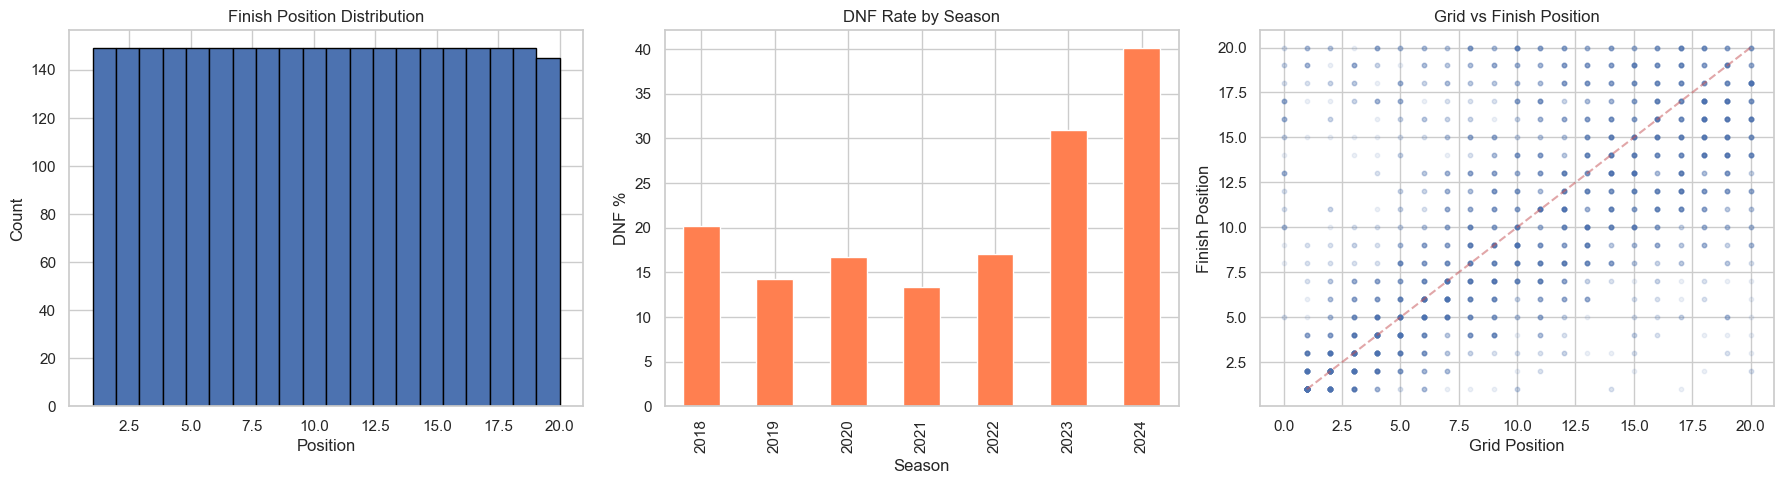

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Finish position distribution
df["finish_position"].dropna().astype(int).hist(bins=20, ax=axes[0], edgecolor="black")
axes[0].set_title("Finish Position Distribution")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Count")

# DNF rate by season
from f1_predictor.data.collect import add_target_variables
df_t = add_target_variables(df)
dnf_by_season = df_t.groupby("season")["is_dnf"].mean() * 100
dnf_by_season.plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("DNF Rate by Season")
axes[1].set_ylabel("DNF %")
axes[1].set_xlabel("Season")

# Grid vs finish position
valid = df.dropna(subset=["grid_position", "finish_position"])
axes[2].scatter(valid["grid_position"], valid["finish_position"], alpha=0.1, s=10)
axes[2].plot([1, 20], [1, 20], "r--", alpha=0.5)
axes[2].set_title("Grid vs Finish Position")
axes[2].set_xlabel("Grid Position")
axes[2].set_ylabel("Finish Position")

plt.tight_layout()
plt.show()

## 3. Driver Win Rates

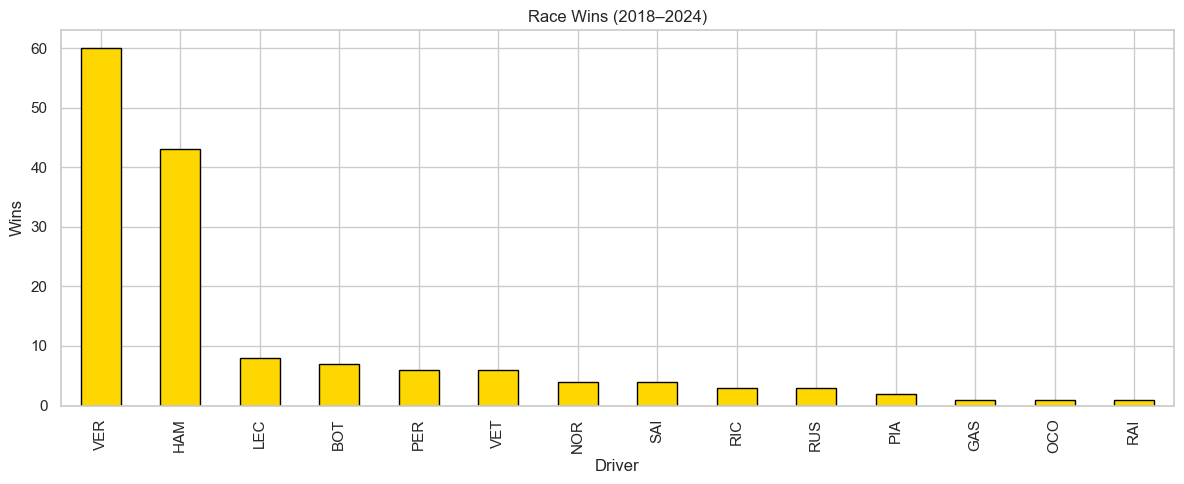

In [4]:
season_start = int(df["season"].min())
season_end = int(df["season"].max())
wins = df[df["finish_position"] == 1].groupby("driver_abbrev").size().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(12, 5))
wins.plot(kind="bar", ax=ax, color="gold", edgecolor="black")
ax.set_title(f"Race Wins ({season_start}\u2013{season_end})")
ax.set_ylabel("Wins")
ax.set_xlabel("Driver")
plt.tight_layout()
plt.show()

## 4. Constructor Dominance by Season

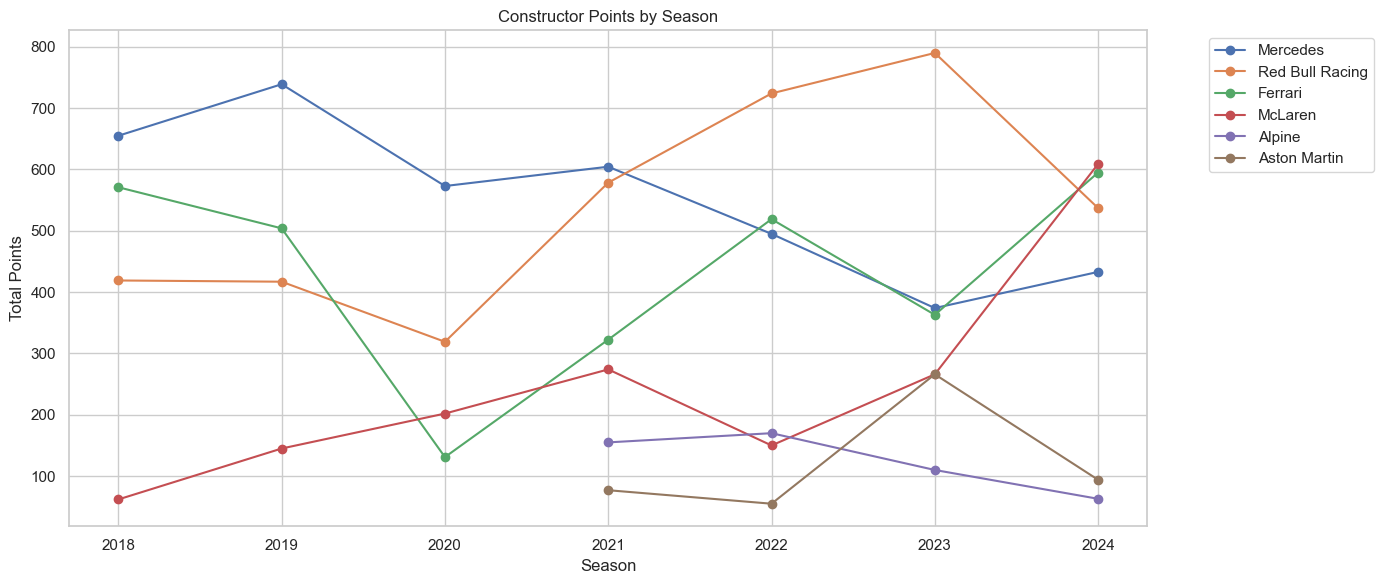

In [5]:
points_by_team = df.groupby(["season", "team"])["points"].sum().reset_index()
top_teams = points_by_team.groupby("team")["points"].sum().nlargest(6).index
filtered = points_by_team[points_by_team["team"].isin(top_teams)]

fig, ax = plt.subplots(figsize=(14, 6))
for team in top_teams:
    team_data = filtered[filtered["team"] == team]
    ax.plot(team_data["season"], team_data["points"], marker="o", label=team)
ax.set_title("Constructor Points by Season")
ax.set_xlabel("Season")
ax.set_ylabel("Total Points")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. Circuit Analysis

Unique circuits: 34

Races per circuit (top 15):
location
Spielberg            5
Barcelona            5
Suzuka               4
Baku                 4
Imola                4
Budapest             4
Sakhir               4
Spa-Francorchamps    4
Silverstone          4
Yas Island           4
Austin               3
Monza                3
Montréal             3
Le Castellet         3
Monaco               3


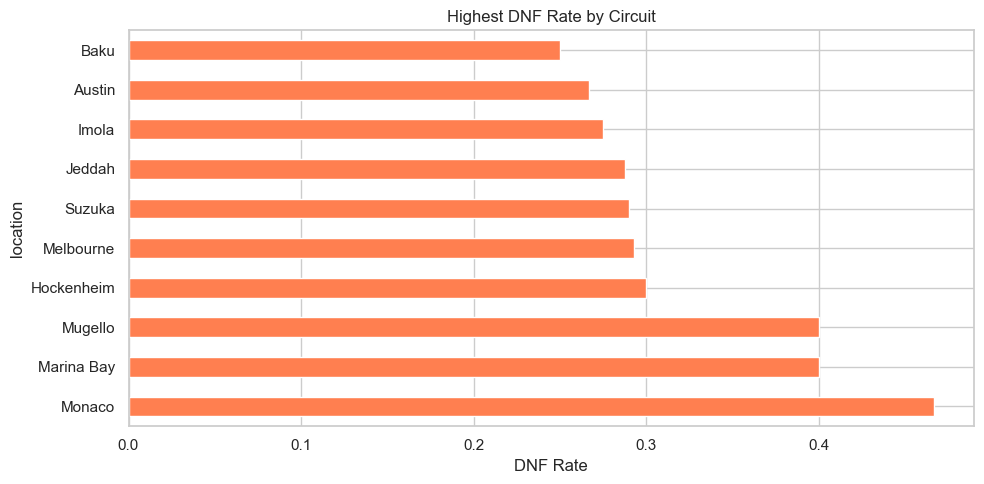

In [6]:
races_per_circuit = df.groupby("location")["round"].nunique().sort_values(ascending=False)
print(f"Unique circuits: {len(races_per_circuit)}")
print(f"\nRaces per circuit (top 15):")
print(races_per_circuit.head(15).to_string())

# Average DNF rate by circuit
dnf_by_circuit = df_t.groupby("location")["is_dnf"].mean().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
dnf_by_circuit.plot(kind="barh", ax=ax, color="coral")
ax.set_title("Highest DNF Rate by Circuit")
ax.set_xlabel("DNF Rate")
plt.tight_layout()
plt.show()

## 6. Weather Impact

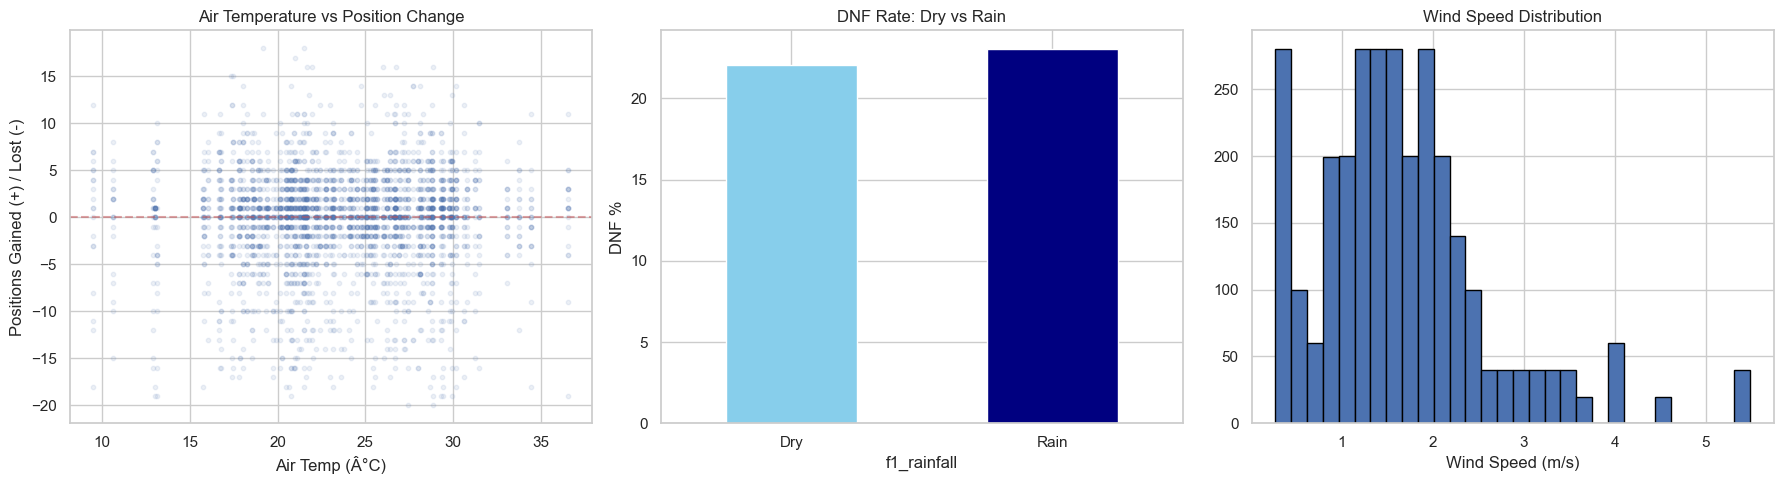

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Temperature vs position change
valid_w = df.dropna(subset=["f1_air_temp_mean", "grid_position", "finish_position"]).copy()
valid_w["position_change"] = valid_w["grid_position"] - valid_w["finish_position"]

axes[0].scatter(valid_w["f1_air_temp_mean"], valid_w["position_change"], alpha=0.1, s=10)
axes[0].axhline(y=0, color="r", linestyle="--", alpha=0.5)
axes[0].set_title("Air Temperature vs Position Change")
axes[0].set_xlabel("Air Temp (Â°C)")
axes[0].set_ylabel("Positions Gained (+) / Lost (-)")

# Rainfall impact on DNFs
rain_data = df_t.dropna(subset=["f1_rainfall"]).copy()
rain_dnf = rain_data.groupby("f1_rainfall")["is_dnf"].mean() * 100
rain_dnf.plot(kind="bar", ax=axes[1], color=["skyblue", "navy"])
axes[1].set_title("DNF Rate: Dry vs Rain")
axes[1].set_ylabel("DNF %")
axes[1].set_xticklabels(["Dry", "Rain"], rotation=0)

# Wind speed distribution
df["f1_wind_speed_mean"].dropna().hist(bins=30, ax=axes[2], edgecolor="black")
axes[2].set_title("Wind Speed Distribution")
axes[2].set_xlabel("Wind Speed (m/s)")

plt.tight_layout()
plt.show()

## 7. Correlation Heatmap

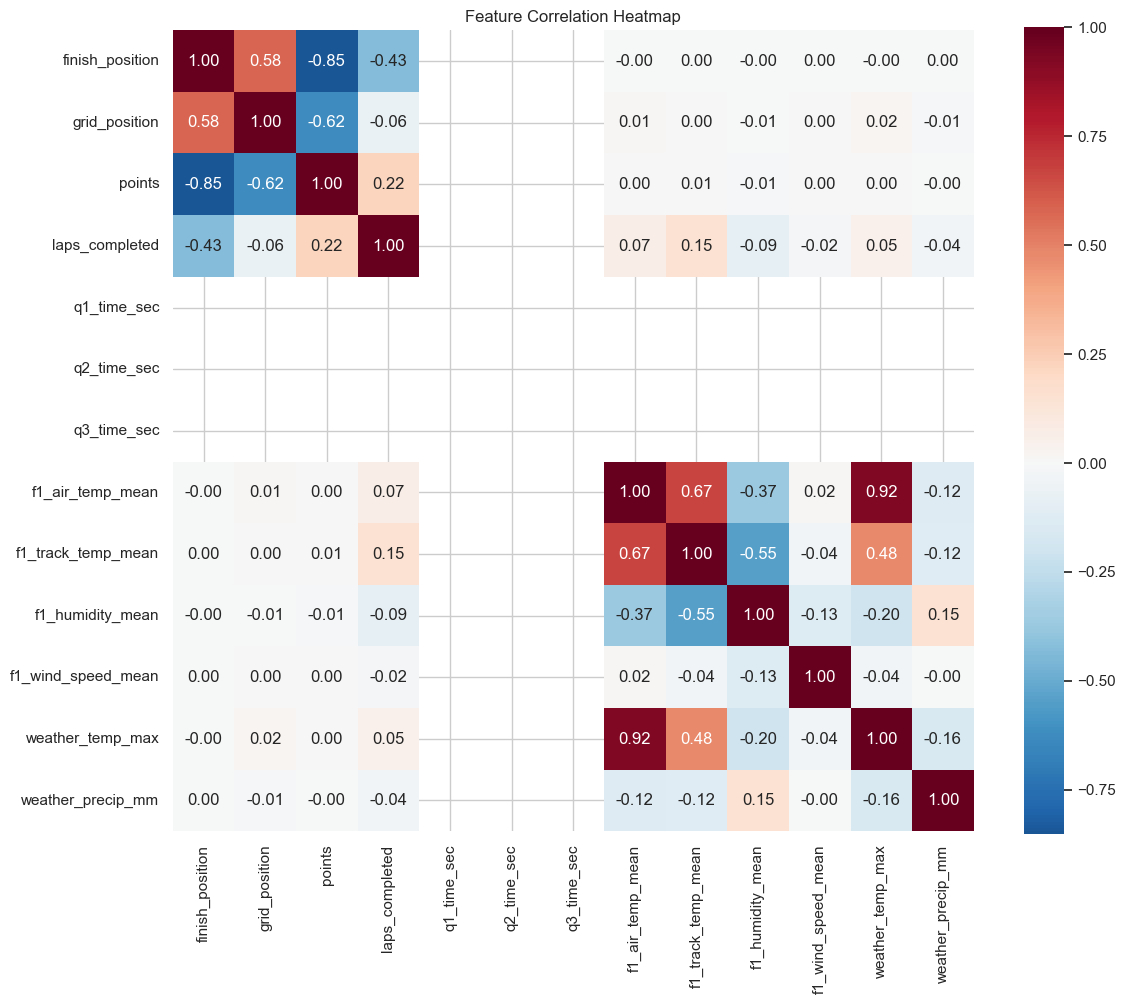

In [8]:
numeric_cols = [
    "finish_position", "grid_position", "points", "laps_completed",
    "q1_time_sec", "q2_time_sec", "q3_time_sec",
    "f1_air_temp_mean", "f1_track_temp_mean", "f1_humidity_mean",
    "f1_wind_speed_mean", "weather_temp_max", "weather_precip_mm",
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 8. Key Insights

- **Grid position** is the strongest predictor of finish position (high correlation)
- **Qualifying times** (Q1/Q2/Q3) are 100% null from race session data â€” need to load qualifying sessions separately in feature engineering
- **Weather** has a moderate effect â€” rain increases DNF rates and shuffle
- **Constructor dominance** shifted from Mercedes (2018-2020) to Red Bull (2021-2023) to McLaren/Ferrari (2024)
- **DNF rates** vary significantly by circuit â€” street circuits and high-altitude tracks tend to have more retirements